# Importing Libraries

In [13]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns 
import plotly.express as px
from  scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats
import sqlite3

# Loading Dataset


In [14]:
#creating database connection 
conn= sqlite3.connect('inventory.db')

# fetching vendor summary data
df=pd.read_sql_query('select * from vendor_sales_summary', conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,actualprice,Volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,FreightCost,Gross Profit,profitmargin,stockturnover,salestopurchaseratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# Exploratory Data Analysis
In the database tables we examined numerous tables and understand their relationships and concluded which should be included in the database.

In this phase of exploratory data analysis will explore the final tables and extract some pattern , anomalies and ensure data quality for further analysis.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10692 non-null  int64  
 1   VendorName             10692 non-null  object 
 2   Brand                  10692 non-null  int64  
 3   Description            10692 non-null  object 
 4   PurchasePrice          10692 non-null  float64
 5   actualprice            10692 non-null  float64
 6   Volume                 10692 non-null  float64
 7   totalpurchasequantity  10692 non-null  int64  
 8   totalpurchasedollars   10692 non-null  float64
 9   totalsalesquantity     10692 non-null  float64
 10  totalsalesdollars      10692 non-null  float64
 11  totalsalesprice        10692 non-null  float64
 12  totalexcisetax         10692 non-null  float64
 13  FreightCost            10692 non-null  float64
 14  Gross Profit           10692 non-null  float64
 15  pr

In [16]:
print(df.columns)


Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'actualprice', 'Volume', 'totalpurchasequantity',
       'totalpurchasedollars', 'totalsalesquantity', 'totalsalesdollars',
       'totalsalesprice', 'totalexcisetax', 'FreightCost', 'Gross Profit',
       'profitmargin', 'stockturnover', 'salestopurchaseratio'],
      dtype='object')


# Statistical Analysis

In [17]:
df.describe().round(0)

,VendorNumber,Brand,PurchasePrice,actualprice,Volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,FreightCost,Gross Profit,profitmargin,stockturnover,salestopurchaseratio
count,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0,10692.0
mean,10651.0,18039.0,24.0,36.0,847.0,3141.0,30107.0,3077.0,42239.0,18794.0,1774.0,61434.0,12132.0,-inf,2.0,3.0
std,18754.0,12662.0,109.0,148.0,664.0,11095.0,123068.0,10953.0,167655.0,44953.0,10976.0,60938.0,46224.0,NaN,6.0,8.0
min,2.0,58.0,0.0,0.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-52003.0,-inf,0.0,0.0
25%,3951.0,5794.0,7.0,11.0,750.0,36.0,453.0,33.0,729.0,290.0,5.0,14070.0,53.0,13.0,1.0,1.0
50%,7153.0,18762.0,10.0,16.0,750.0,262.0,3655.0,261.0,5298.0,2858.0,47.0,50294.0,1400.0,30.0,1.0,1.0
75%,9552.0,25514.0,19.0,29.0,750.0,1976.0,20738.0,1929.0,28397.0,16060.0,419.0,79529.0,8660.0,40.0,1.0,2.0
max,201359.0,90631.0,5682.0,7500.0,20000.0,337660.0,3811252.0,334939.0,5101920.0,672819.0,368243.0,257032.0,1290668.0,100.0,274.0,353.0


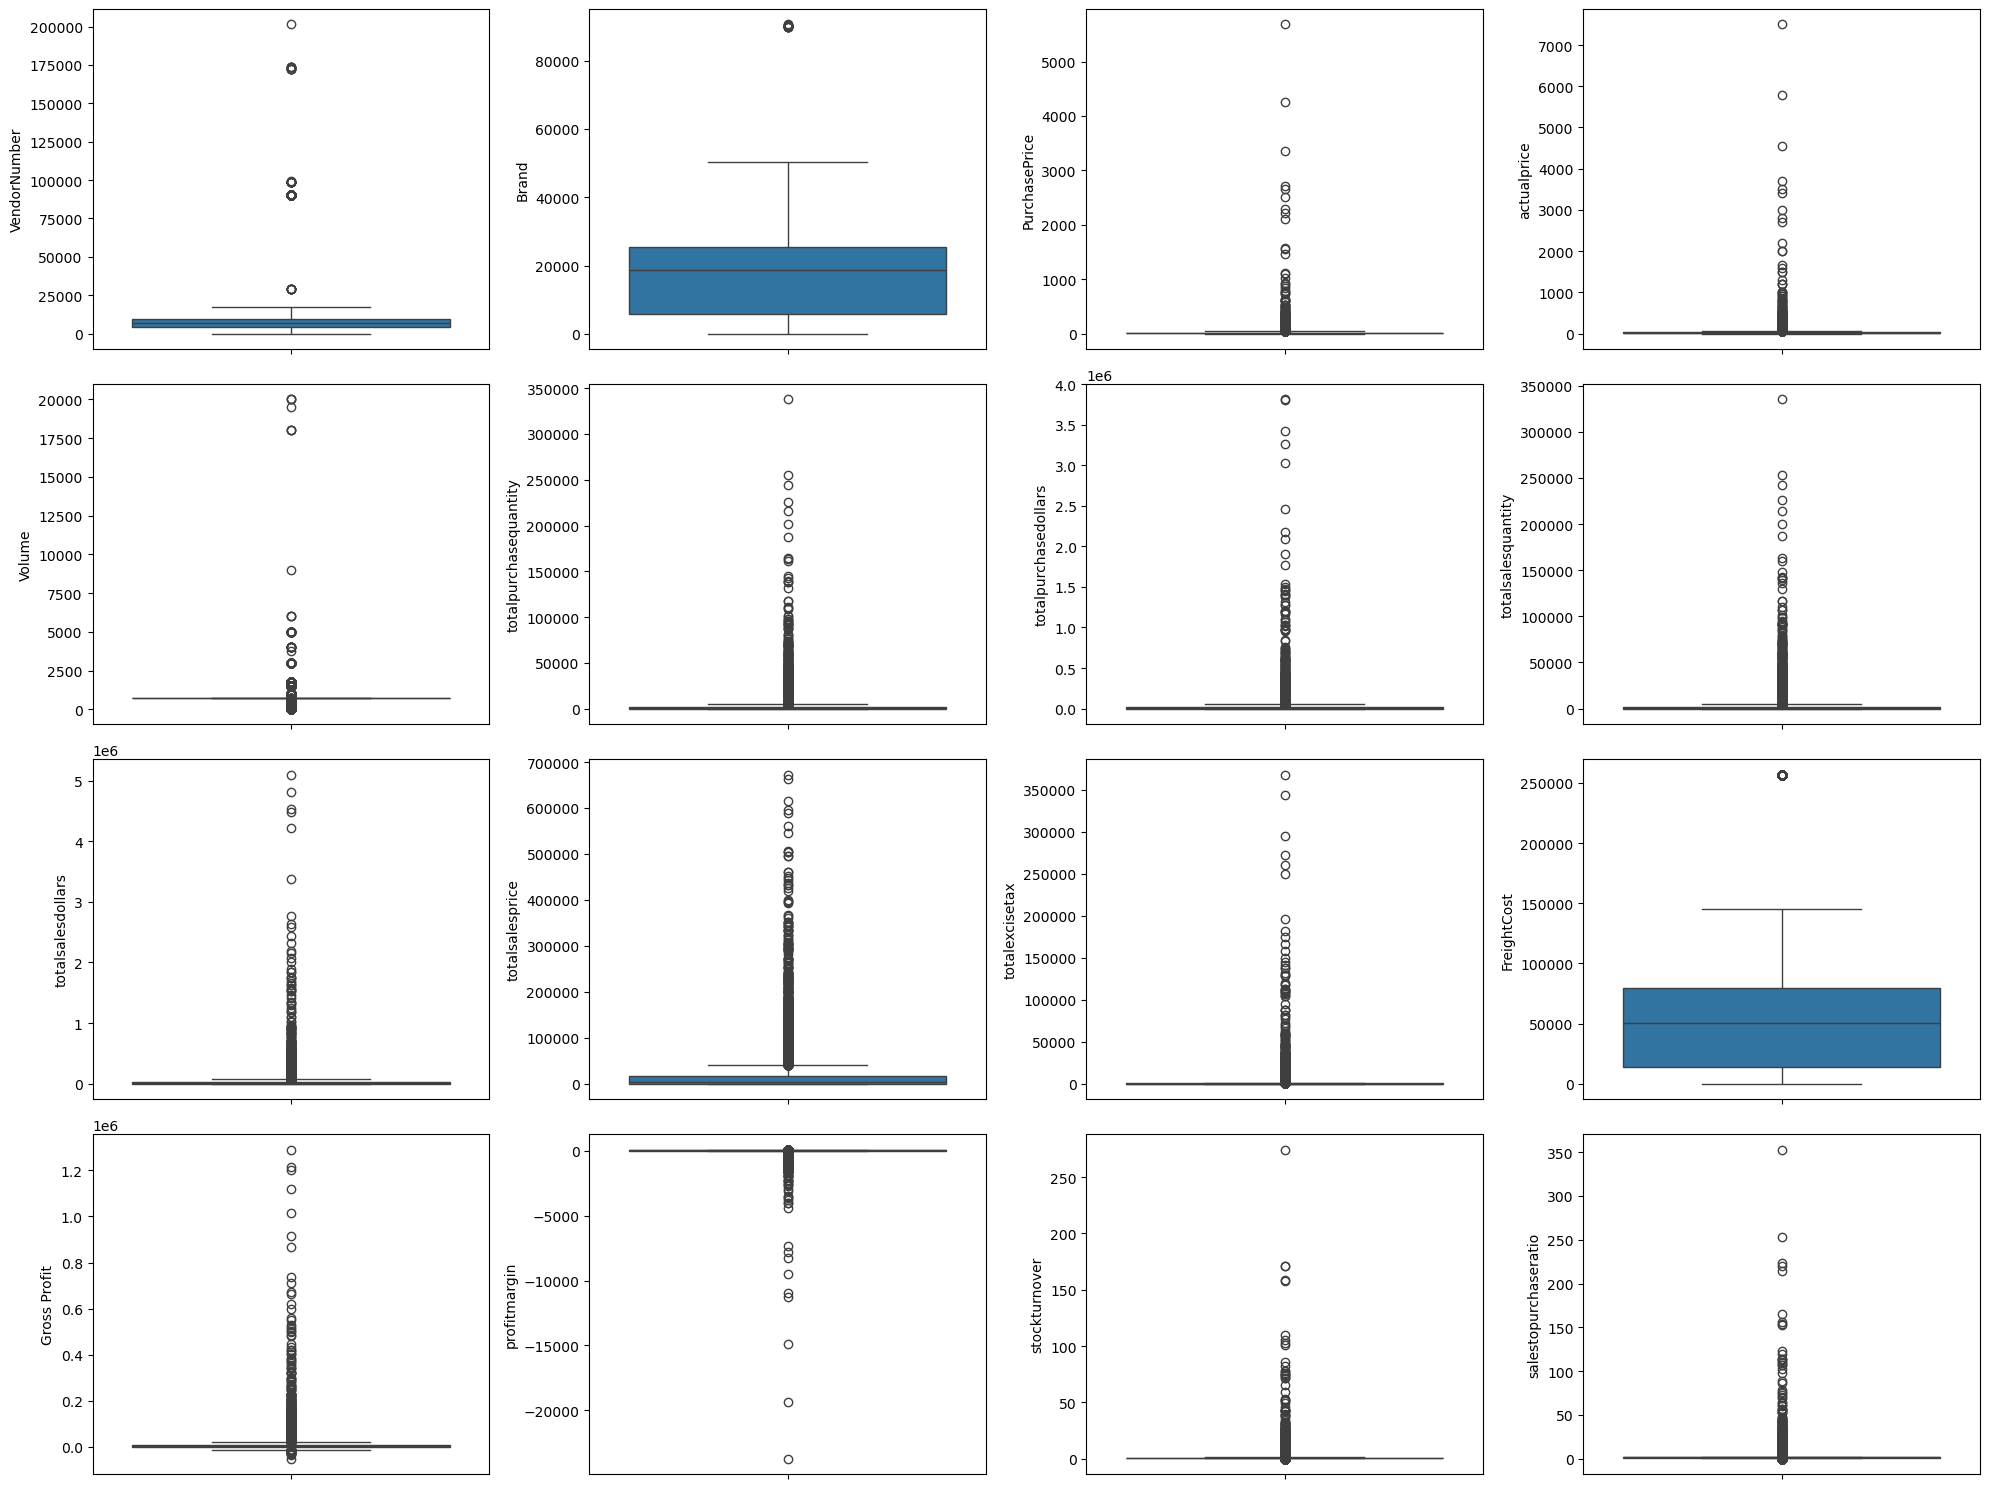

In [18]:
plt.figure(figsize=(20,15))
numeric_col= df.select_dtypes(include=np.number).columns
for  i , col in enumerate(numeric_col):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

# Insights :
**Negative and Zero Values**
Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations**:

Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales being fulfilled from older stock



In [19]:
#filter the data by removing the inconsistencies
df=pd.read_sql_query(""" select * from 
vendor_sales_summary
where [Gross Profit]>0
and profitmargin>0
and totalsalesquantity>0 """, conn)

In [21]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,actualprice,Volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,FreightCost,Gross Profit,profitmargin,stockturnover,salestopurchaseratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


# Count plot Description and VendorName

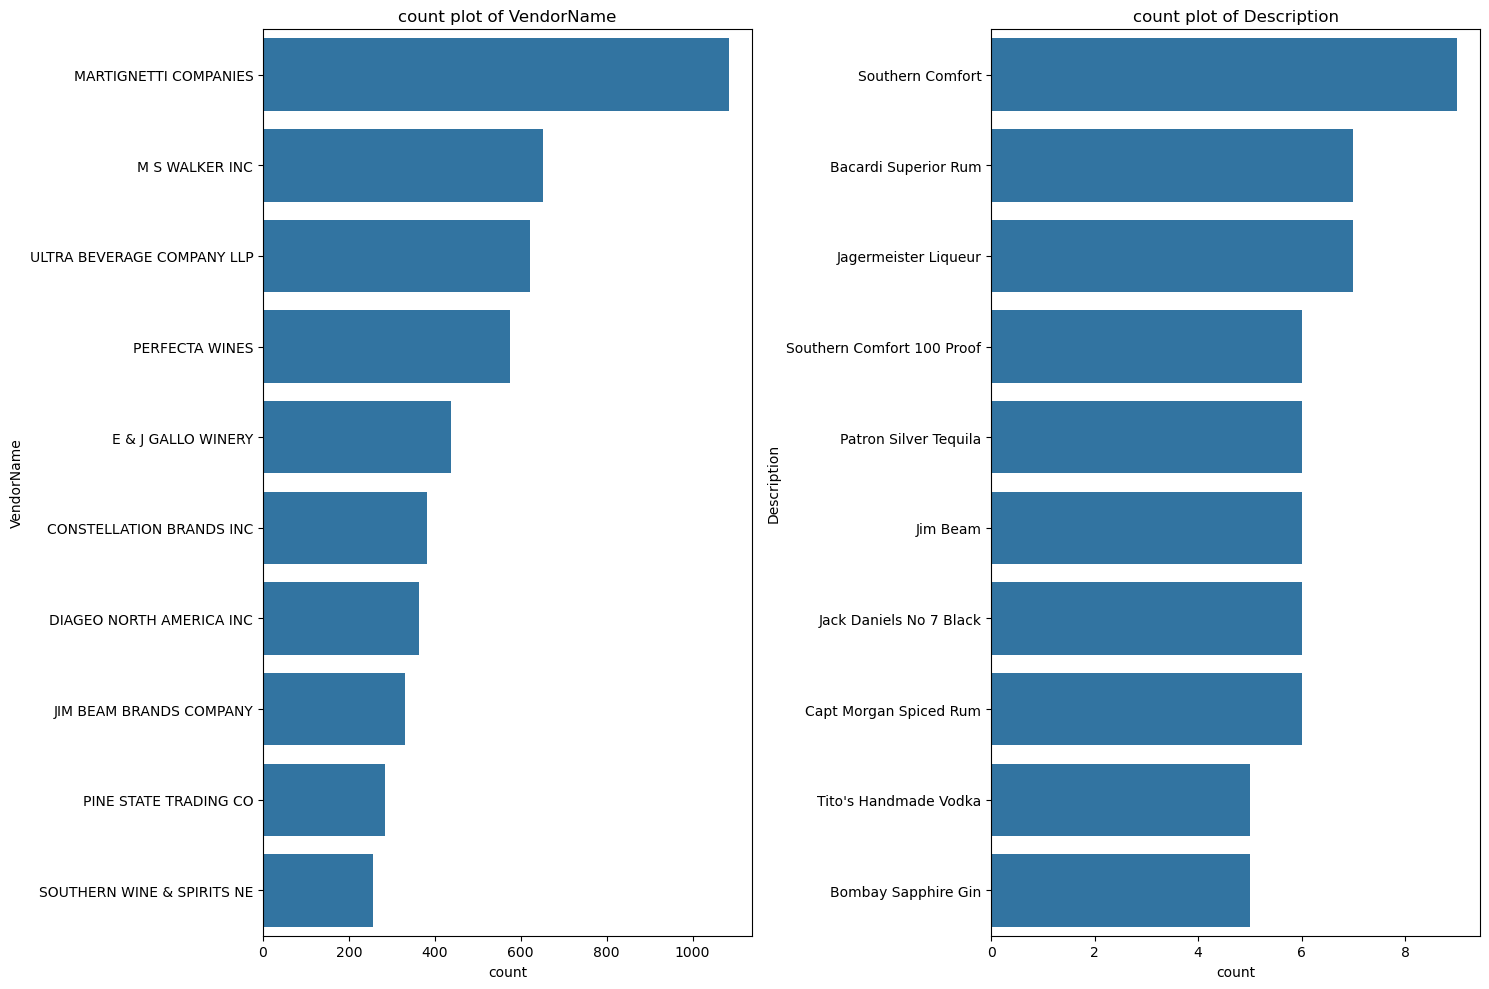

In [39]:
categorical_col= ['VendorName','Description']
plt.figure(figsize=(15,10))
for i , col in enumerate(categorical_col):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f'count plot of {col}')
plt.tight_layout()
plt.show()

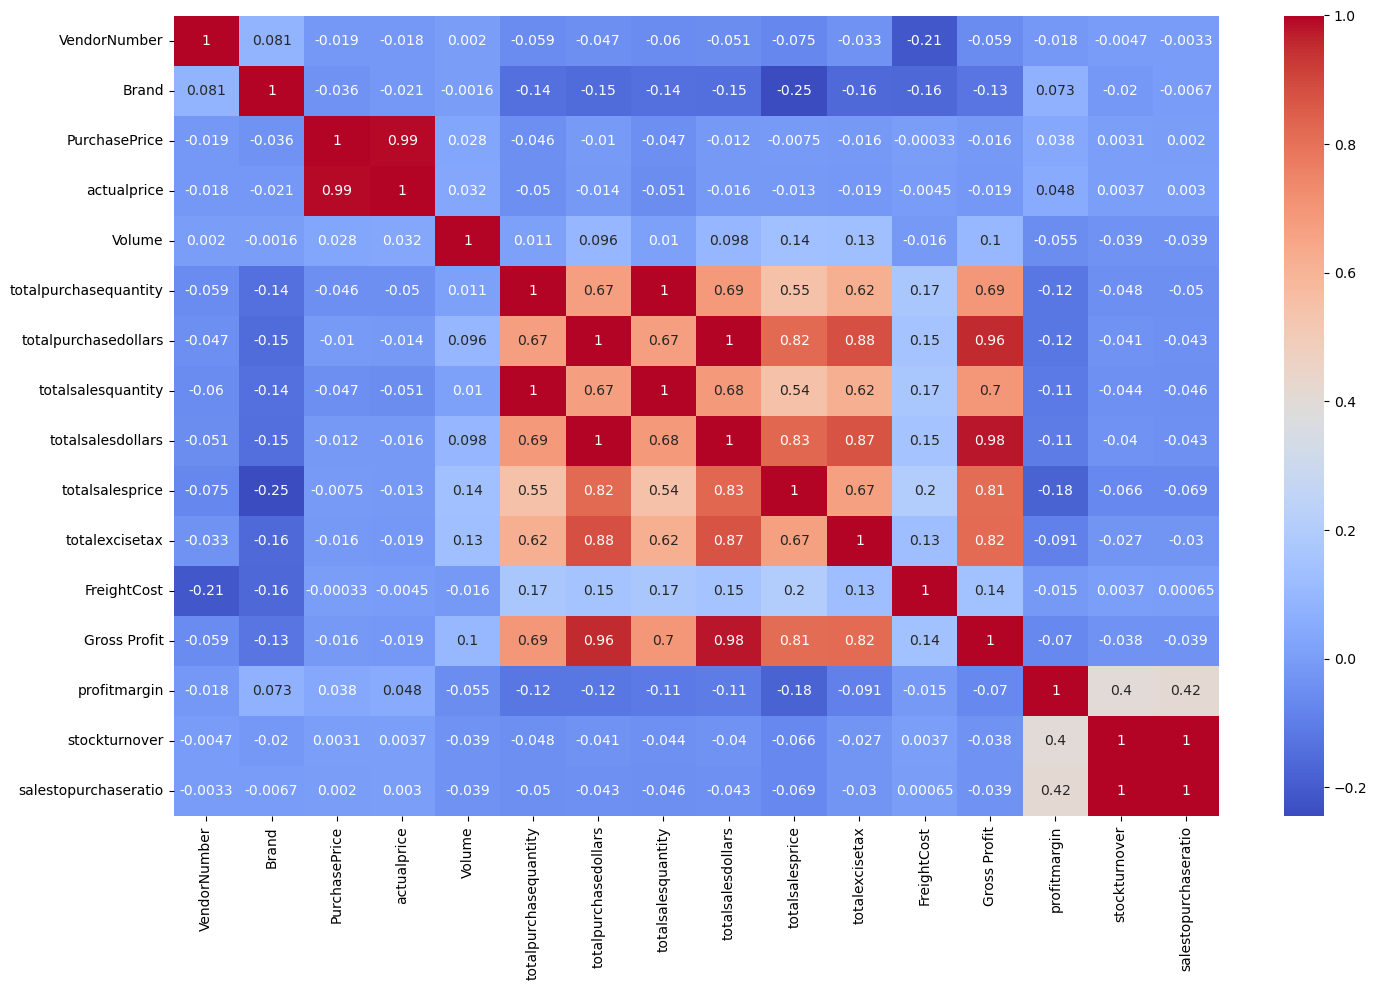

In [45]:
corr_df=df.corr(numeric_only=True)
plt.figure(figsize=(15,10))
sns.heatmap(corr_df,annot=True , cmap='coolwarm')
plt.tight_layout()
plt.show()

# Correlation Insights:
- Purchase price has weak correlation with totalsalesdollar(-0.012) and grossprofit(-0.016) , suggesting that price variation do not significantly impacting sales revenue and profit 

- Strong Correlation between total purchase quantity and total sales quantity (1) confirming efficient inventory turnover.

- Negative correlation between profit margin and total sales price(-0.179) suggests that as sales price increases, margin decreases, possibly due to competitive pricing pressure

- Stock Turnover has weak negative correlation with both gross profit(-0.038)and profit margin (-0.055) , indicating that faster turnover does not necessarily result in higher profitably
    

# Data Analysis

**Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margin**

In [64]:
brand_performance=df.groupby('Description').agg({'totalsalesdollars':'sum' , 'profitmargin':'mean'}).reset_index()
brand_performance

,Description,totalsalesdollars,profitmargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [65]:
low_sales_threshold=brand_performance['totalsalesdollars'].quantile(0.15)
high_margin_threshold=brand_performance['profitmargin'].quantile(0.85)

In [67]:
low_sales_threshold

np.float64(560.299)

In [68]:
high_margin_threshold

np.float64(64.97017552750113)

In [80]:
#filter brands with low sales and high marginprofit
target_brands = brand_performance[
    (brand_performance['totalsalesdollars'] <= low_sales_threshold) &
    (brand_performance['profitmargin'] >= high_margin_threshold)
]

print("Brands with low Sales but High Profit Margin")

display(target_brands.sort_values('totalsalesdollars'))

Brands with low Sales but High Profit Margin


,Description,totalsalesdollars,profitmargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [81]:
brand_performance=brand_performance[brand_performance['totalsalesdollars']<10000]

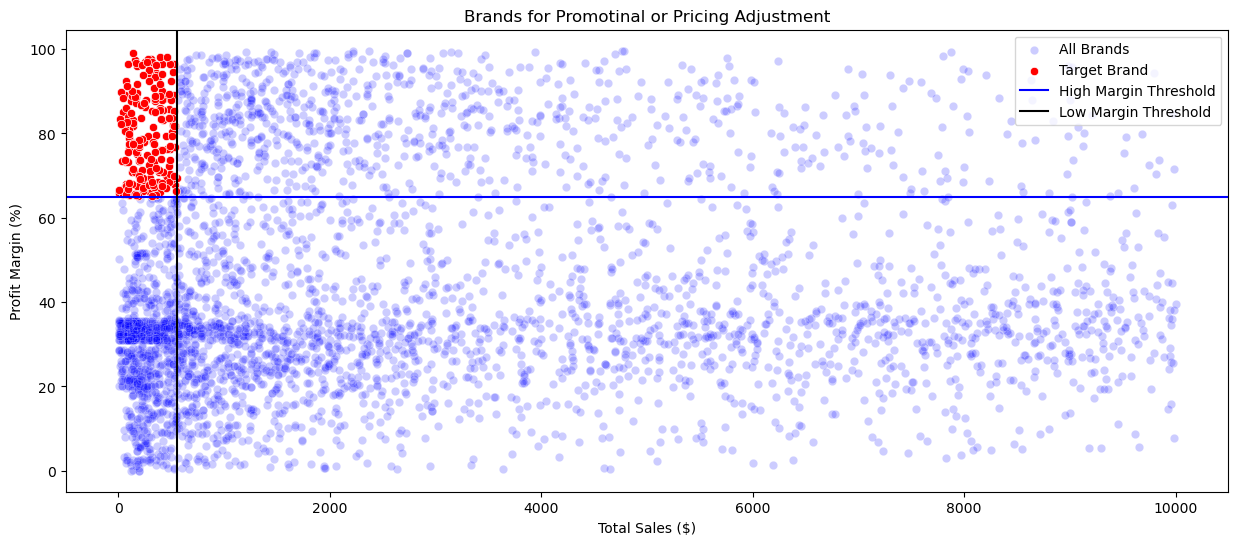

In [83]:
plt.figure(figsize=(15,6))
sns.scatterplot(data=brand_performance , x='totalsalesdollars',y='profitmargin',color='blue',label='All Brands',alpha=0.2)
sns.scatterplot(data=target_brands , x='totalsalesdollars', y='profitmargin',color='red',label='Target Brand')

plt.axhline(high_margin_threshold,color='blue',label='High Margin Threshold')
plt.axvline(low_sales_threshold ,  color='black',label='Low Margin Threshold')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brands for Promotinal or Pricing Adjustment')
plt.legend()
plt.show()


# Which vendors and brands demonstrate the  highest Sales Performance?

In [89]:
top_vendors=df.groupby('VendorName')['totalsalesdollars'].sum().nlargest(10)
top_brands=df.groupby('Description')['totalsalesdollars'].sum().nlargest(10)


In [155]:
def format_dollars(value):
    if value>=1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_000:.2f}k"
    else :
        return str(value)

In [91]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: totalsalesdollars, dtype: object

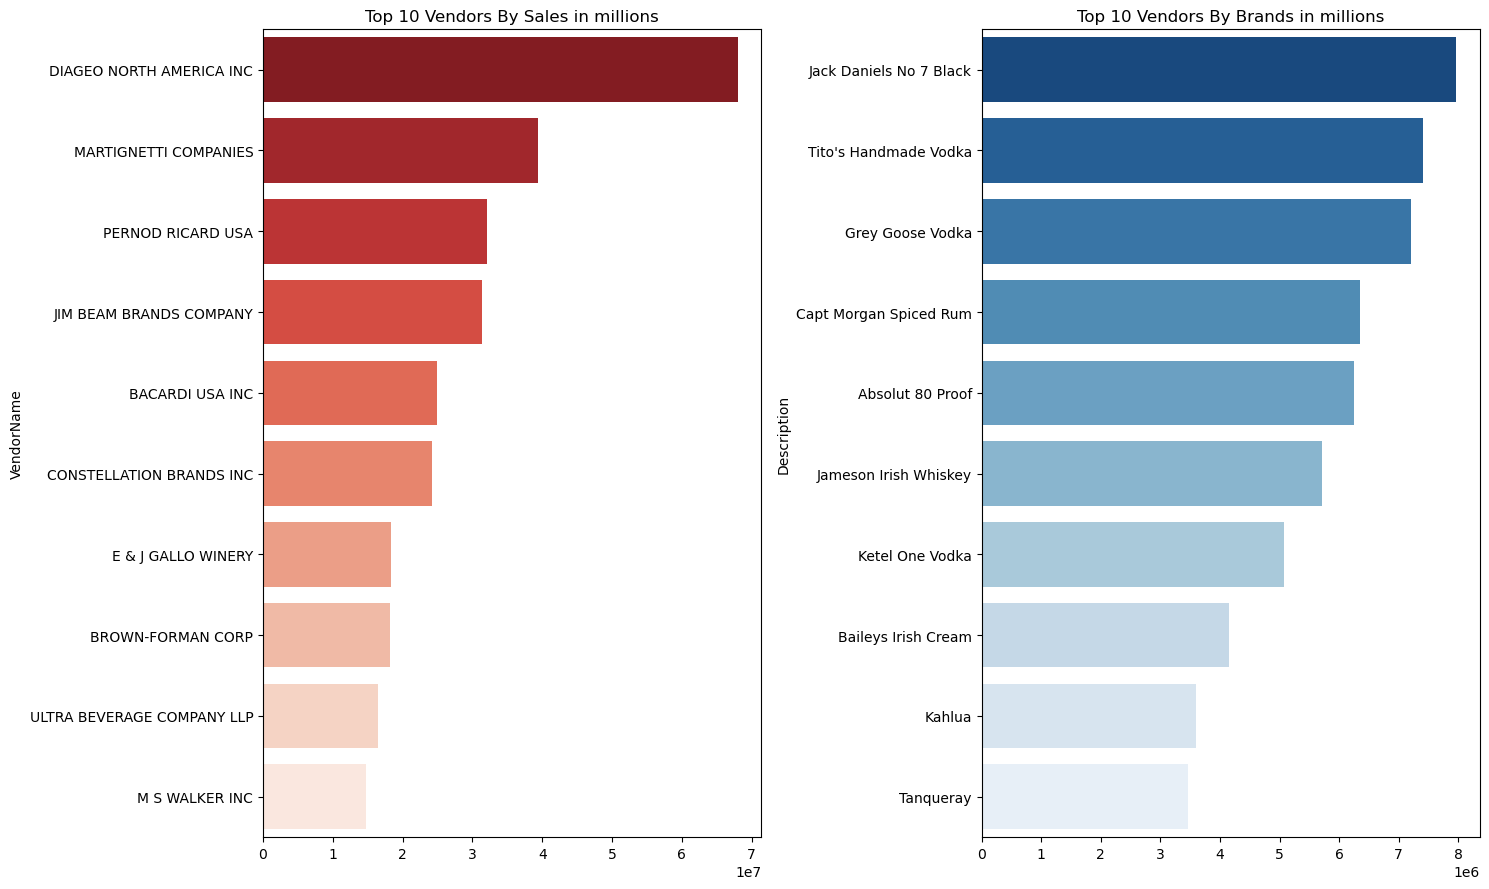

In [93]:
plt.figure(figsize=(15,9))
plt.subplot(121)
sns.barplot(y=top_vendors.index , x=top_vendors.values , palette='Reds_r')
plt.title('Top 10 Vendors By Sales in millions')

plt.subplot(122)
sns.barplot(y=top_brands.index , x=top_brands.values, palette='Blues_r')
plt.title('Top 10 Vendors By Brands in millions')

plt.tight_layout()
plt.show()

# Which Vendors Contributed The Most To Total Purchase Dollars?

In [94]:
vendor_performance = df.groupby("VendorName").agg({"totalpurchasedollars":'sum','Gross Profit': 'sum','totalsalesdollars':'sum'}).reset_index()

In [95]:
vendor_performance

,VendorName,totalpurchasedollars,Gross Profit,totalsalesdollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [103]:
vendor_performance['Purchase Contribution Percentage(%)']= vendor_performance['totalpurchasedollars']/sum(vendor_performance['totalpurchasedollars'])*100

In [104]:
vendor_performance=round(vendor_performance.sort_values('Purchase Contribution Percentage(%)', ascending=False),2)

In [105]:
# top 10 vendors
top_vendors=vendor_performance.head(10)
top_vendors['totalsalesdollars']=top_vendors['totalsalesdollars'].apply(format_dollars)
top_vendors['totalpurchasedollars']=top_vendors['totalpurchasedollars'].apply(format_dollars)
top_vendors['Gross Profit']=top_vendors['Gross Profit'].apply(format_dollars)
top_vendors

,VendorName,totalpurchasedollars,Gross Profit,totalsalesdollars,Purchase Contribution Percentage,Purchase Contribution Percentage(%)
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,3.18


In [107]:
print(f'Total Contribution in Purchase of Top 10 Vendors:{round(top_vendors['Purchase Contribution Percentage'].sum(),2)}%')

Total Contribution in Purchase of Top 10 Vendors:65.69%


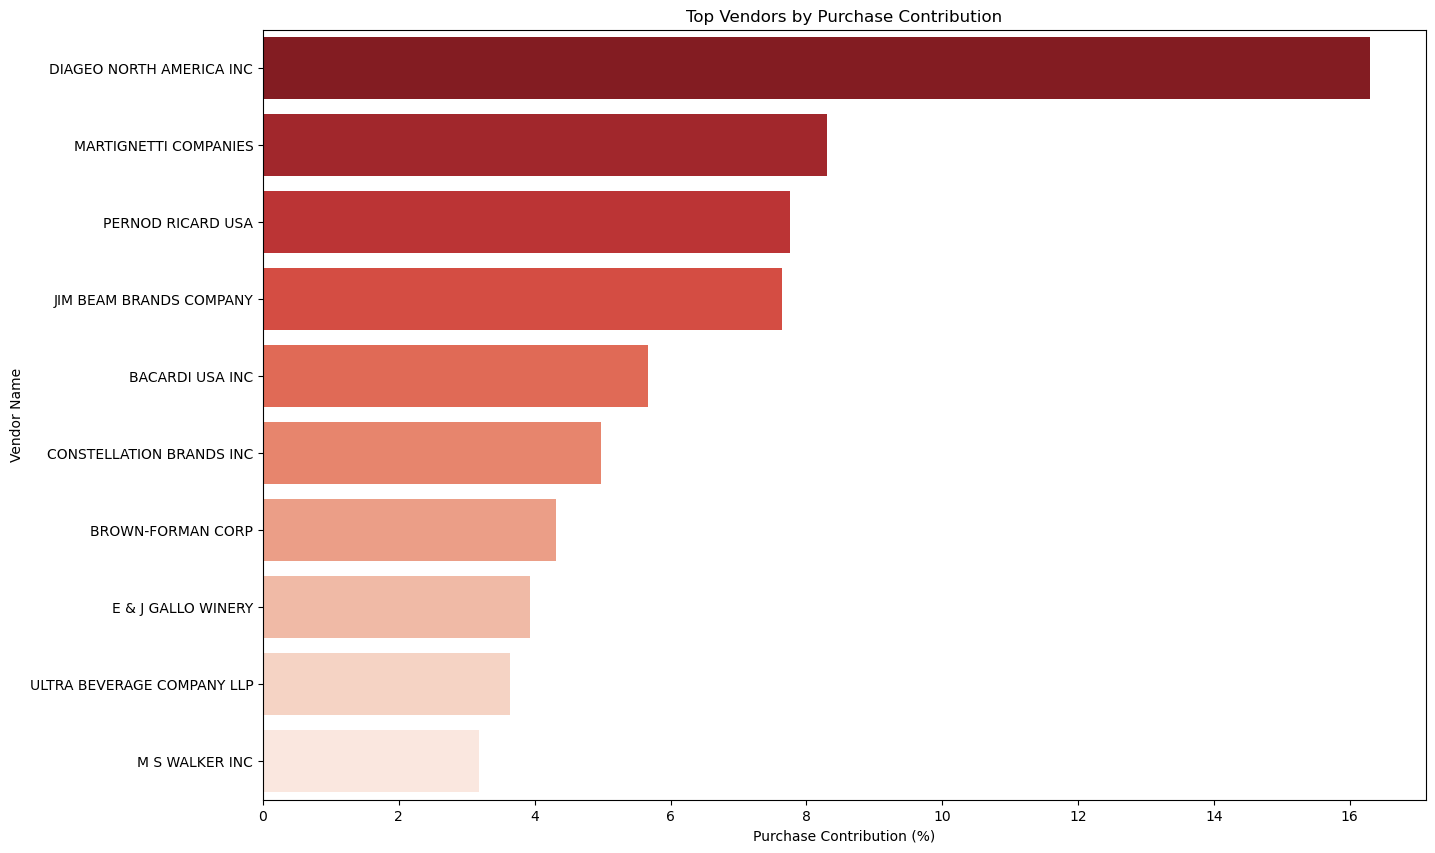

In [122]:
plt.figure(figsize=(15,10))

sns.barplot(x=top_vendors['Purchase Contribution Percentage(%)'],y=top_vendors['VendorName'], palette='Reds_r')
plt.xlabel("Purchase Contribution (%)")
plt.ylabel("Vendor Name")
plt.title("Top Vendors by Purchase Contribution")

plt.show()

# Does Purchasing in bulk reduce the  unit price , and what is the optimal purchase volume for cost saving?

In [123]:
df['Unit Purchase Price']= df['totalpurchasedollars']/df['totalpurchasequantity']

In [125]:
df['Order Size']=pd.qcut(df['totalpurchasequantity'], q=3 ,labels=['small','medium','large'] )

In [126]:
df['Order Size'].value_counts()

Order Size
small     2856
large     2855
medium    2853
Name: count, dtype: int64

In [127]:
df.groupby('Order Size')[['Unit Purchase Price']].mean()

,Unit Purchase Price
Order Size,
small,39.068186
medium,15.486414
large,10.777625


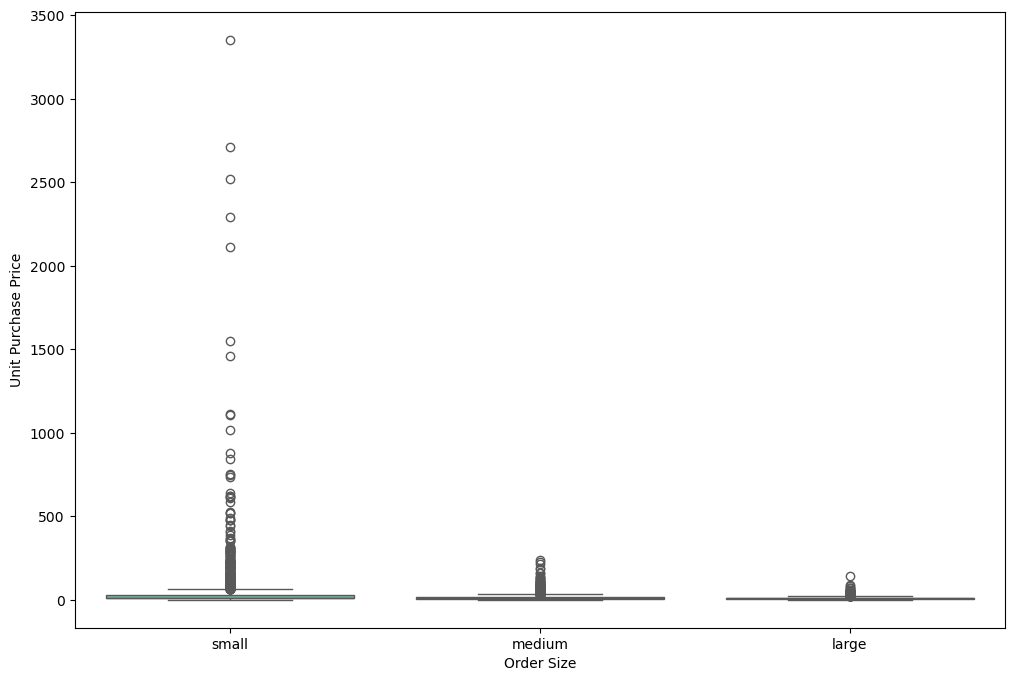

In [131]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x='Order Size',y='Unit Purchase Price',palette='Set2')
plt.show()



- Vendors Buying in Bulk (large order size) get the lowest unit price ($10.78 per unit) , meaning high margin if they can manage inventory efficiently.
- The Price difference Small and Large order is substantial(72% reduction in unit price)
- This suggest that bulk pricing strategy successfully encourages vendors to purchase in large volume , leading to higher overall sales despite lower per unit revenue.

# which vendors have low inventory turnover , indicating excess stock and slow-moving products?

In [132]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,actualprice,Volume,totalpurchasequantity,totalpurchasedollars,totalsalesquantity,totalsalesdollars,totalsalesprice,totalexcisetax,FreightCost,Gross Profit,profitmargin,stockturnover,salestopurchaseratio,Unit Purchase Price,Order Size
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27,large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19,large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24,large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17,large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89,large


In [136]:
df[df['stockturnover']<1].groupby('VendorName')[['stockturnover']].mean().sort_values('stockturnover', ascending=True).head(5)

,stockturnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022


# How much capital is locked in unsold inventory per vendor and which vendor contribute it the most?

In [148]:
df['Unsold Inventory Value']=(df['totalpurchasequantity']-df['totalsalesquantity'])*df['PurchasePrice']
print(f'Total Unsold Capital:{format_dollars(df['Unsold Inventory Value'].sum())}')

Total Unsold Capital:2.71M


In [156]:
# Aggregate Capital locked per vendor 
inventory_value_per_vendor=df.groupby('VendorName')['Unsold Inventory Value'].sum().reset_index()

# sort value with highest locked capital
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by='Unsold Inventory Value', ascending=False)
inventory_value_per_vendor['Unsold Inventory Value']=inventory_value_per_vendor['Unsold Inventory Value'].apply(format_dollars)
inventory_value_per_vendor.head(10)     

,VendorName,Unsold Inventory Value
25,DIAGEO NORTH AMERICA INC,722.21k
46,JIM BEAM BRANDS COMPANY,554.67k
68,PERNOD RICARD USA,470.63k
116,WILLIAM GRANT & SONS INC,401.96k
30,E & J GALLO WINERY,228.28k
79,SAZERAC CO INC,198.44k
11,BROWN-FORMAN CORP,177.73k
20,CONSTELLATION BRANDS INC,133.62k
61,MOET HENNESSY USA INC,126.48k
77,REMY COINTREAU USA INC,118.60k


**What is the 95% Confidence Interval for Profit Margin of Top-Performing and Low Performing Vendor?**

In [157]:
top_threshold=df['totalsalesdollars'].quantile(.75)
low_threshold=df['totalsalesdollars'].quantile(.25)

In [158]:
top_vendors=df[df['totalsalesdollars']>= top_threshold]['profitmargin'].dropna()
bottom_vendors=df[df['totalsalesdollars']<= top_threshold]['profitmargin'].dropna()

In [159]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: profitmargin, Length: 2141, dtype: float64

In [161]:
bottom_vendors

1622     0.568840
1646     2.513325
1786    12.479372
1803    14.366830
1812    12.428142
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: profitmargin, Length: 6423, dtype: float64

In [168]:
def confidence_interval(data, confidence=0.95):
    mean_val=np.mean(data)
    std_err=np.std(data)/np.sqrt(len(data))
    t_critical=stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical*std_err
    return mean_val , mean_val-margin_of_error, mean_val+margin_of_error


Top Vendor 95% CI: 31.61 ,30.74, mean : 31.18
Top Vendor 95% CI: 41.81 ,40.67, mean : 41.24


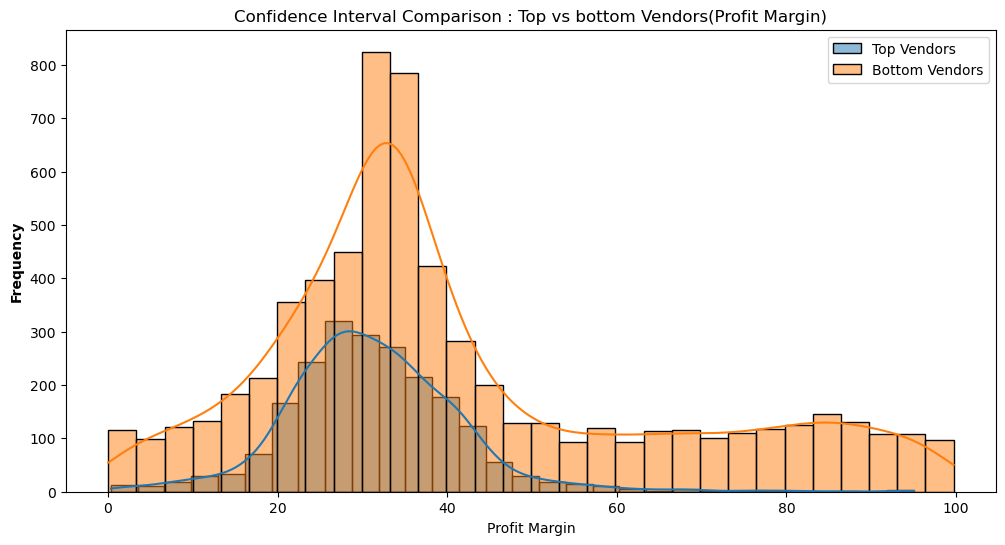

In [174]:
top_mean , top_upper ,top_lower = confidence_interval(top_vendors)
bottom_mean , bottom_upper , bottom_lower=confidence_interval(bottom_vendors)

print(f'Top Vendor 95% CI: {top_lower:.2f} ,{top_upper:.2f}, mean : {top_mean:.2f}')
print(f'Top Vendor 95% CI: {bottom_lower:.2f} ,{bottom_upper:.2f}, mean : {bottom_mean:.2f}')

plt.figure(figsize=(12,6))

sns.histplot(top_vendors , kde=True , bins=30, label='Top Vendors')
sns.histplot(bottom_vendors, kde=True , bins=30,label='Bottom Vendors')

plt.title('Confidence Interval Comparison : Top vs bottom Vendors(Profit Margin)')
plt.ylabel('Frequency',fontweight='bold')
plt.xlabel('Profit Margin')
plt.legend()
plt.show()




-The confidence interval for low-performing vendors (40.48% to 42.62%) is noticeably higher compared to top-performing vendors (30.74% to 31.61%).

-This indicates that vendors with lower sales often achieve higher profit margins, possibly due to premium pricing strategies or lower operating costs.

-For high-performing vendors, improving profitability may involve strategies such as selective price adjustments, cost optimization, or product bundling.

-For low-performing vendors, although margins are higher, the lower sales volume suggests a need to enhance marketing efforts, adopt competitive pricing, or improve distribution strategies.

# HYPOTHESIS TESTING

**Is there a significant difference in the profit margin between the top performing and bottom performing vendors?**

H0(Null Hypothesis): There is a significant difference in the mean profit margin of top performing and bottom performing vendors

H1(Alternate Hypothesis): There is no change in the mean profit margin of top performing and bottom performing vendors

In [178]:
top_threshold=df['totalsalesdollars'].quantile(.75)
low_threshold=df['totalsalesdollars'].quantile(.25)

top_vendors=df[df['totalsalesdollars']>= top_threshold]['profitmargin'].dropna()
bottom_vendors=df[df['totalsalesdollars']<= top_threshold]['profitmargin'].dropna()

# two sample ttest
t_stat , p_value = ttest_ind(top_vendors , bottom_vendors , equal_var=False )
print(f"t-statistics : {t_stat:.4f} , p-value={p_value:.4f}")
if p_value < 0.05 :
    print('H0(Null Hypothesis): There is a significant difference in the mean profit margin of top performing and bottom performing vendors')
else :
    print('Fail to Reject H0: No significat difference in profit margin')




t-statistics : -27.3996 , p-value=0.0000
H0(Null Hypothesis): There is a significant difference in the mean profit margin of top performing and bottom performing vendors
